# LoRA (Low-Rank Adaptation) from Scratch

Build order:
1. **Stage 1** — Linear algebra foundations: rank, low-rank decomposition, SVD
2. **Stage 2** — Implement LoRA layer from scratch
3. **Stage 3** — Inject LoRA into a transformer and train
4. **Stage 4** — Training dynamics: initialization, scaling, rank sensitivity
5. **Stage 5** — Weight merging and inference

**Core idea before starting:**

A pretrained weight matrix `W ∈ R^{d×k}` is frozen. Instead of fine-tuning all `d×k`
parameters, we add a low-rank bypass:

```
h = Wx + BAx
  = (W + BA)x

where  B ∈ R^{d×r},  A ∈ R^{r×k},  r << min(d, k)
```

Trainable params: `r×(d+k)` vs original `d×k`.  
For d=k=4096, r=8: **0.2%** of original parameters.

Why does this work? The hypothesis is that the update ΔW during fine-tuning
has **intrinsically low rank** — the task-specific signal lives in a small subspace.

## Setup

In [1]:
!pip install torch matplotlib --quiet


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import math
import copy
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field
from typing import Optional
from collections import defaultdict

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


---
## Stage 1 — Linear Algebra Foundations

Before implementing LoRA, build intuition for:
- What matrix rank means in practice
- How SVD decomposes a matrix into rank-1 components
- Why fine-tuning updates might be low-rank

### 1a — Matrix rank and low-rank approximation via SVD

In [6]:
def low_rank_approx(W: torch.Tensor, rank: int) -> torch.Tensor:
    """
    Approximate W using its top-`rank` singular components.

    SVD: W = U @ diag(S) @ V^T
    Keep only top-r singular values/vectors:
      W_r = U[:, :r] @ diag(S[:r]) @ V[:, :r]^T

    This is the best rank-r approximation of W in the Frobenius norm
    (Eckart-Young theorem).

    Returns W_r  (same shape as W)

    TODO: implement.
    Hint: torch.linalg.svd(W, full_matrices=False)  returns U, S, Vh
          Note: torch returns Vh (V transposed), not V
    """
    U, S, V = torch.linalg.svd(W, full_matrices=False)
    Ur = U[:, :rank]
    Sr = S[:rank]
    Vr = V[:rank, :]
    Wr = Ur @ torch.diag(Sr) @ Vr
    return Wr

def reconstruction_error(W: torch.Tensor, W_approx: torch.Tensor) -> float:
    """
    Frobenius norm of the approximation error, normalized by W's norm.
    Error = ||W - W_approx||_F / ||W||_F

    TODO: implement.
    """
    return (W - W_approx).norm("fro") / W.norm("fro")

def explained_variance(W: torch.Tensor, rank: int) -> float:
    """
    Fraction of total variance (sum of squared singular values)
    captured by the top-`rank` singular values.

    explained = sum(S[:rank]^2) / sum(S^2)

    TODO: implement.
    """
    S = torch.linalg.svdvals(W)
    return (S[:rank] ** 2).sum().item() / (S ** 2).sum().item()

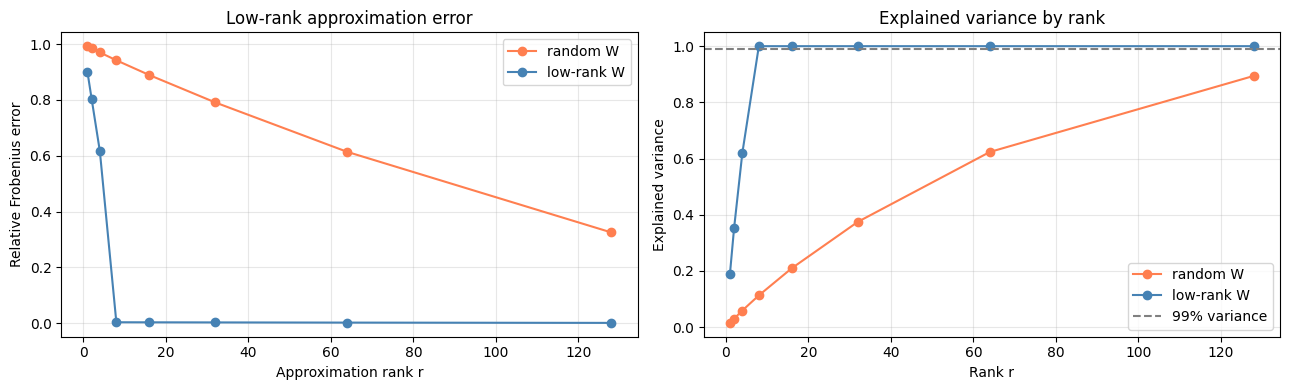

r=  1  random: 0.015  low-rank: 0.191
r=  2  random: 0.030  low-rank: 0.353
r=  4  random: 0.059  low-rank: 0.620
r=  8  random: 0.113  low-rank: 1.000
r= 16  random: 0.210  low-rank: 1.000
r= 32  random: 0.375  low-rank: 1.000
r= 64  random: 0.623  low-rank: 1.000
r=128  random: 0.894  low-rank: 1.000


In [7]:
# --- Experiment: how well can a random full-rank matrix be approximated at low rank? ---
d, k = 256, 256
ranks = [1, 2, 4, 8, 16, 32, 64, 128]

# Case 1: truly random matrix (high effective rank)
W_random = torch.randn(d, k)

# Case 2: low-rank matrix + small noise (low effective rank)
# Simulate what a fine-tuning update might look like
r_true = 8
W_lowrank = torch.randn(d, r_true) @ torch.randn(r_true, k) + 0.01 * torch.randn(d, k)

errors_random  = [reconstruction_error(W_random,  low_rank_approx(W_random,  r)) for r in ranks]
errors_lowrank = [reconstruction_error(W_lowrank, low_rank_approx(W_lowrank, r)) for r in ranks]
varexp_random  = [explained_variance(W_random,  r) for r in ranks]
varexp_lowrank = [explained_variance(W_lowrank, r) for r in ranks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(ranks, errors_random,  "o-", label="random W",   color="coral")
ax1.plot(ranks, errors_lowrank, "o-", label="low-rank W", color="steelblue")
ax1.set_xlabel("Approximation rank r"); ax1.set_ylabel("Relative Frobenius error")
ax1.set_title("Low-rank approximation error"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ranks, varexp_random,  "o-", label="random W",   color="coral")
ax2.plot(ranks, varexp_lowrank, "o-", label="low-rank W", color="steelblue")
ax2.axhline(0.99, linestyle="--", color="gray", label="99% variance")
ax2.set_xlabel("Rank r"); ax2.set_ylabel("Explained variance")
ax2.set_title("Explained variance by rank"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Key question: what rank explains 99% of variance in each case?
for r, ev_r, ev_l in zip(ranks, varexp_random, varexp_lowrank):
    print(f"r={r:>3}  random: {ev_r:.3f}  low-rank: {ev_l:.3f}")

### 1b — Singular value spectrum of pretrained weights

The LoRA paper's key empirical observation: pretrained weight matrices
have a **rapidly decaying singular value spectrum**. This means updates
don't need to span the full space.

In [ ]:
def plot_singular_value_spectrum(matrices: dict, title: str = "Singular value spectra"):
    """
    Plot normalized singular values for multiple matrices.
    Normalization: divide by the largest singular value.

    matrices: dict of {label: tensor}

    TODO: implement.
    Use torch.linalg.svdvals for efficiency (no need for U, Vh).
    """
    raise NotImplementedError

# Simulate weight matrices with different effective ranks
def make_pretrained_weight(d, k, effective_rank=32, noise=0.01):
    """Simulate a pretrained weight: low-rank signal + small noise."""
    signal = torch.randn(d, effective_rank) @ torch.randn(effective_rank, k)
    noise_mat = noise * torch.randn(d, k)
    W = signal + noise_mat
    return W / W.norm()  # normalize for fair comparison

matrices = {
    "random (no structure)": torch.randn(256, 256),
    "pretrained-like (r=32)": make_pretrained_weight(256, 256, effective_rank=32),
    "pretrained-like (r=8)":  make_pretrained_weight(256, 256, effective_rank=8),
}
plot_singular_value_spectrum(matrices)

### 1c — Why BA decomposes as a rank-r update

This is the core linear algebra claim of LoRA.

In [ ]:
def verify_lora_rank(d: int, k: int, r: int):
    """
    Verify that BA has rank exactly r (or less).

    B ∈ R^{d×r}, A ∈ R^{r×k}
    rank(BA) ≤ min(rank(B), rank(A)) ≤ r

    TODO:
      1. Create random B and A
      2. Compute delta_W = B @ A
      3. Compute numerical rank using torch.linalg.matrix_rank
      4. Print shapes, rank of delta_W, and trainable param count vs full
    """
    raise NotImplementedError

for r in [1, 4, 8, 16]:
    verify_lora_rank(d=512, k=512, r=r)

---
## Stage 2 — LoRA Layer Implementation

Implement `LoRALinear` — a drop-in replacement for `nn.Linear` that:
- Freezes the original weight W
- Adds trainable low-rank matrices A and B
- Scales the update by α/r
- Can merge B and A into W at inference time

In [ ]:
class LoRALinear(nn.Module):
    """
    Linear layer with LoRA bypass.

    Forward:
      h = W x  +  (B A x) × (alpha / r)

    Parameters:
      W:     frozen pretrained weight [out_features, in_features]
      A:     trainable  [r, in_features]  — initialized from N(0, sigma^2)
      B:     trainable  [out_features, r] — initialized to ZERO
      alpha: scaling hyperparameter (typically equal to r)

    Why initialize B=0?
      At the start of fine-tuning, delta_W = BA = 0.
      The model starts exactly at the pretrained checkpoint.
      If B were random, the initial output would be corrupted.

    Why the alpha/r scaling?
      Decouples the learning rate from r.
      When you change r, you don't need to retune lr.
      With alpha=r, scaling=1 (no effect). With alpha=2r, scaling=2.
    """
    def __init__(
        self,
        in_features:  int,
        out_features: int,
        rank:         int   = 4,
        alpha:        float = None,   # defaults to rank
        bias:         bool  = True,
    ):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.rank         = rank
        self.alpha        = alpha if alpha is not None else float(rank)
        self.scaling      = self.alpha / self.rank
        self.merged       = False

        # Frozen pretrained weight
        # TODO: create self.weight as a frozen parameter
        # Hint: use nn.Parameter with requires_grad=False
        # Initialize with kaiming_uniform_ like nn.Linear does
        raise NotImplementedError

        if bias:
            self.bias = nn.Parameter(torch.zeros(out_features))
        else:
            self.register_parameter("bias", None)

        # Trainable LoRA matrices
        # TODO: create self.lora_A [rank, in_features]  — use nn.Parameter
        # TODO: create self.lora_B [out_features, rank] — use nn.Parameter
        raise NotImplementedError

        self.reset_lora_parameters()

    def reset_lora_parameters(self):
        """
        Initialize LoRA weights.
        A ~ N(0, 1/in_features)  (kaiming-style for stable forward pass)
        B = 0                    (so delta_W = 0 at init)

        TODO: implement.
        Use nn.init.kaiming_uniform_ for A (like the paper),
        nn.init.zeros_ for B.
        """
        raise NotImplementedError

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        h = W x + scaling × B A x

        TODO: implement.
        Hint:
          base_output = F.linear(x, self.weight, self.bias)
          lora_output = F.linear(F.linear(x, self.lora_A), self.lora_B)
          return base_output + self.scaling * lora_output

        Edge case: if self.merged is True, only apply base (weights already merged).
        """
        raise NotImplementedError

    def merge_weights(self):
        """
        Merge LoRA update into W in-place:
          W ← W + scaling × B @ A

        After merging, forward() uses only W (no extra compute).
        This is how LoRA achieves zero inference overhead.

        TODO: implement.
        Guard with `if not self.merged` to avoid double-merging.
        After merge: set self.merged = True.
        """
        raise NotImplementedError

    def unmerge_weights(self):
        """
        Undo the merge (useful to resume training after merging):
          W ← W - scaling × B @ A

        TODO: implement.
        Guard with `if self.merged`.
        """
        raise NotImplementedError

    def trainable_parameters(self) -> int:
        """Count trainable parameters (A + B only, not W)."""
        return self.lora_A.numel() + self.lora_B.numel()

    def extra_repr(self) -> str:
        return (f"in={self.in_features}, out={self.out_features}, "
                f"r={self.rank}, alpha={self.alpha}, merged={self.merged}")

In [ ]:
# --- Correctness checks ---

layer = LoRALinear(in_features=64, out_features=32, rank=4, alpha=4)
x     = torch.randn(8, 64)

# 1. At init, delta_W should be exactly zero (B=0)
delta_W = layer.scaling * layer.lora_B @ layer.lora_A
assert delta_W.abs().max().item() == 0.0, "B should be zero at init"
print("✓ delta_W = 0 at initialization")

# 2. Output at init should match frozen W exactly
base_out = F.linear(x, layer.weight, layer.bias)
lora_out = layer(x)
assert torch.allclose(base_out, lora_out, atol=1e-6), "LoRA output should match base at init"
print("✓ LoRA output matches base at initialization")

# 3. After training (fake update to B), outputs should differ
with torch.no_grad():
    layer.lora_B.data = torch.randn_like(layer.lora_B)
lora_out_trained = layer(x)
assert not torch.allclose(base_out, lora_out_trained)
print("✓ LoRA output changes after B is updated")

# 4. Merge/unmerge should be exact inverse
out_before_merge = layer(x).clone()
layer.merge_weights()
assert layer.merged
out_after_merge = layer(x)
assert torch.allclose(out_before_merge, out_after_merge, atol=1e-5), "Merge should preserve outputs"
print("✓ merge_weights() preserves output")

layer.unmerge_weights()
assert not layer.merged
out_after_unmerge = layer(x)
assert torch.allclose(out_before_merge, out_after_unmerge, atol=1e-5), "Unmerge should restore outputs"
print("✓ unmerge_weights() restores original behavior")

# 5. Parameter counts
total  = layer.weight.numel() + (layer.bias.numel() if layer.bias is not None else 0)
lora_p = layer.trainable_parameters()
print(f"\nFull params: {total:,}  |  LoRA trainable: {lora_p:,}  |  Ratio: {lora_p/total:.2%}")

# 6. Frozen weight should not appear in optimizer
trainable = [p for p in layer.parameters() if p.requires_grad]
assert not any(p is layer.weight for p in trainable), "W should be frozen"
print("✓ W is frozen (not in requires_grad params)")

### 2b — Compare parameter counts across ranks

In [ ]:
def lora_param_efficiency(
    d_model: int = 4096,
    ranks:   list = [1, 2, 4, 8, 16, 32, 64],
    n_layers: int = 32,
    target_modules: int = 4,  # q, k, v, o projections per layer
) -> None:
    """
    Print parameter efficiency table for a transformer-style model.

    For each rank r, compute:
      - Params per LoRA layer: r*(d+d) = 2*r*d  (square matrices)
      - Total LoRA params: n_layers × target_modules × 2rd
      - Full fine-tune params: n_layers × target_modules × d²
      - Ratio: LoRA / full

    TODO: implement and print a formatted table.
    """
    raise NotImplementedError

lora_param_efficiency()

---
## Stage 3 — Inject LoRA into a Transformer and Train

Apply LoRA to the attention projections of a small GPT-style model.
Train on a simple synthetic task to verify end-to-end.

In [ ]:
@dataclass
class GPTConfig:
    vocab_size: int   = 256
    seq_len:    int   = 64
    n_layers:   int   = 4
    d_model:    int   = 128
    n_heads:    int   = 4
    d_ff:       int   = 512
    dropout:    float = 0.1

class CausalSelfAttention(nn.Module):
    def __init__(self, cfg: GPTConfig, linear_cls=nn.Linear):
        """
        linear_cls lets us swap in LoRALinear for any of the projections.
        """
        super().__init__()
        self.n_heads = cfg.n_heads
        self.d_head  = cfg.d_model // cfg.n_heads
        self.q_proj  = linear_cls(cfg.d_model, cfg.d_model, bias=False)
        self.k_proj  = linear_cls(cfg.d_model, cfg.d_model, bias=False)
        self.v_proj  = linear_cls(cfg.d_model, cfg.d_model, bias=False)
        self.o_proj  = linear_cls(cfg.d_model, cfg.d_model, bias=False)
        self.drop    = nn.Dropout(cfg.dropout)
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(cfg.seq_len, cfg.seq_len)).view(1,1,cfg.seq_len,cfg.seq_len)
        )

    def forward(self, x):
        B, T, C = x.shape
        def reshape(t):
            return t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = reshape(self.q_proj(x)), reshape(self.k_proj(x)), reshape(self.v_proj(x))
        att = (q @ k.transpose(-2,-1)) / math.sqrt(self.d_head)
        att = att.masked_fill(self.mask[:,:,:T,:T] == 0, float("-inf"))
        att = self.drop(torch.softmax(att, dim=-1))
        out = (att @ v).transpose(1,2).contiguous().view(B, T, C)
        return self.o_proj(out)

class TransformerBlock(nn.Module):
    def __init__(self, cfg: GPTConfig, linear_cls=nn.Linear):
        super().__init__()
        self.ln1  = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg, linear_cls)
        self.ln2  = nn.LayerNorm(cfg.d_model)
        self.ff   = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.d_ff, cfg.d_model),
        )
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class TinyGPT(nn.Module):
    def __init__(self, cfg: GPTConfig, linear_cls=nn.Linear):
        super().__init__()
        self.embed  = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos    = nn.Embedding(cfg.seq_len, cfg.d_model)
        self.blocks = nn.ModuleList([TransformerBlock(cfg, linear_cls) for _ in range(cfg.n_layers)])
        self.ln_f   = nn.LayerNorm(cfg.d_model)
        self.head   = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)

    def forward(self, idx):
        B, T = idx.shape
        x = self.embed(idx) + self.pos(torch.arange(T, device=idx.device))
        for block in self.blocks:
            x = block(x)
        return self.head(self.ln_f(x))

    def count_params(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable

In [ ]:
def inject_lora(
    model:       nn.Module,
    rank:        int   = 4,
    alpha:       float = None,
    target_modules: list = ["q_proj", "v_proj"],
) -> nn.Module:
    """
    Replace target nn.Linear modules with LoRALinear in-place.
    Freeze all parameters, then unfreeze LoRA A and B.

    Steps:
      1. Freeze all params: p.requires_grad = False
      2. Walk the model with named_modules()
      3. For each target module (by name suffix), replace with LoRALinear
         and copy the pretrained weight over
      4. Unfreeze lora_A and lora_B in replaced modules

    Returns the modified model.

    TODO: implement.
    Hint for replacing a child module:
      parent = model.get_submodule(parent_name)
      setattr(parent, child_name, new_module)
    """
    raise NotImplementedError

# Build a base model and inject LoRA
cfg        = GPTConfig()
base_model = TinyGPT(cfg).to(device)
lora_model = copy.deepcopy(base_model)
lora_model = inject_lora(lora_model, rank=4, target_modules=["q_proj", "v_proj"])

total, trainable = lora_model.count_params()
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Trainable ratio:  {trainable/total:.2%}")
print()
# Show which modules are trainable
for name, p in lora_model.named_parameters():
    if p.requires_grad:
        print(f"  trainable: {name}  {tuple(p.shape)}")

### 3b — Synthetic task: copy task

Simple task: given a token sequence, predict the same sequence shifted by 1.
The base model is pretrained on random data; we fine-tune with LoRA.

In [ ]:
def make_copy_batch(batch_size: int, seq_len: int, vocab_size: int, device):
    """
    Copy task: input = random tokens, target = same tokens.
    i.e. the model must learn to repeat what it sees.
    """
    tokens = torch.randint(0, vocab_size, (batch_size, seq_len), device=device)
    return tokens, tokens

def train_loop(
    model,
    n_steps:    int   = 500,
    batch_size: int   = 16,
    lr:         float = 1e-3,
    label:      str   = "model",
) -> dict:
    """
    Train model on the copy task.
    Record loss, gradient norms, and delta_W norms at each step.

    Returns dict with keys: losses, grad_norms, delta_W_norms (if LoRA)

    TODO: implement.
    Notes:
      - Use AdamW optimizer, only pass requires_grad parameters
      - CrossEntropyLoss: logits [B,T,V] → reshape to [B*T, V], targets [B*T]
      - Gradient norm: compute over all trainable params
      - delta_W norm: for LoRA layers, track (scaling * B @ A).norm().item()
    """
    raise NotImplementedError

In [ ]:
# Train both full fine-tune and LoRA, compare
# Full fine-tune: unfreeze everything
full_model = copy.deepcopy(base_model)
for p in full_model.parameters():
    p.requires_grad = True

print("Training full fine-tune...")
full_stats = train_loop(full_model, n_steps=500, lr=1e-3, label="full")

print("Training LoRA...")
lora_model = copy.deepcopy(base_model)
lora_model = inject_lora(lora_model, rank=4, target_modules=["q_proj", "v_proj"])
lora_stats = train_loop(lora_model, n_steps=500, lr=1e-3, label="lora")

In [ ]:
# Plot: loss curves + gradient norms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# TODO: plot loss, grad norms, and delta_W growth over training steps
# Panel 1: loss curves for full vs LoRA
# Panel 2: gradient norm over steps for both
# Panel 3: delta_W = ||BA||_F norm over steps (LoRA only) — shows how much the update grows

raise NotImplementedError

---
## Stage 4 — Training Dynamics

Three key dynamics to understand:
1. Initialization sensitivity (what happens if B is not zero?)
2. Rank sensitivity (how does r affect convergence?)
3. Alpha/scaling sensitivity (how does alpha interact with lr?)

### 4a — Why B=0 initialization matters

In [ ]:
class LoRALinearBadInit(LoRALinear):
    """
    LoRA with random initialization of B (bad practice).
    Use this to demonstrate why B=0 is necessary.
    """
    def reset_lora_parameters(self):
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.lora_B, a=math.sqrt(5))  # <-- not zero!

def run_init_experiment() -> dict:
    """
    Compare:
      (a) LoRA with B=0 init (correct)
      (b) LoRA with B=random init (bad)

    Measure:
      - Initial loss (should be similar for both)
      - Loss after 200 steps
      - Initial gradient magnitude

    TODO: implement.
    Create both models from the same base, inject with different LoRA classes,
    run train_loop for 200 steps, compare.
    """
    raise NotImplementedError

init_results = run_init_experiment()

### 4b — Rank sensitivity

In [ ]:
def rank_sensitivity_experiment(
    ranks: list = [1, 2, 4, 8, 16, 32],
    n_steps: int = 300,
) -> dict:
    """
    Train LoRA at each rank, record:
      - Final loss
      - Trainable param count
      - Effective rank of learned delta_W = BA
        (use torch.linalg.matrix_rank with a tolerance)

    TODO: implement.
    After training, for each LoRA layer, compute delta_W = scaling * B @ A
    and measure its effective rank.
    """
    raise NotImplementedError

rank_results = rank_sensitivity_experiment()

# TODO: plot final loss vs rank, and effective rank of delta_W vs allocated rank
# The second plot is the most informative: if effective_rank << allocated_rank,
# the model is learning a structure even lower-rank than r.

### 4c — Alpha / scaling sensitivity

Alpha controls the magnitude of the LoRA update relative to the base.
Too small → LoRA has no effect. Too large → destabilizes training.

In [ ]:
def alpha_sensitivity_experiment(
    rank:    int   = 8,
    alphas:  list  = [0.5, 1, 2, 4, 8, 16, 32],
    n_steps: int   = 300,
    lr:      float = 1e-3,
) -> dict:
    """
    Train LoRA with fixed rank but varying alpha.
    Record final loss and delta_W norm at each alpha.

    Key relationship to understand:
      effective_lr_for_lora ∝ lr × (alpha / r)
    So alpha acts as a multiplier on the learning rate for the LoRA update.

    TODO: implement.
    """
    raise NotImplementedError

alpha_results = alpha_sensitivity_experiment()

# TODO: plot final loss vs alpha/rank ratio (scaling factor)
# The sweet spot is typically alpha/rank ≈ 1-2

### 4d — Intrinsic rank: does the learned update have lower rank than r?

In [ ]:
def analyze_learned_delta_W(lora_model: nn.Module) -> None:
    """
    For each LoRA layer in the model:
      1. Compute delta_W = scaling * B @ A
      2. Compute its SVD
      3. Plot the singular value spectrum
      4. Measure effective rank

    This answers: does the task need the full rank-r budget,
    or does it converge to something lower?

    TODO: implement.
    Collect all LoRA layers via isinstance(module, LoRALinear),
    compute delta_W for each, plot spectra side by side.
    """
    raise NotImplementedError

analyze_learned_delta_W(lora_model)

---
## Stage 5 — Weight Merging and Inference

LoRA's key practical advantage: at inference time you can merge B and A
into W, eliminating all extra compute. This is how LoRA achieves the same
latency as the original model.

In [ ]:
def merge_all_lora_layers(model: nn.Module) -> nn.Module:
    """
    Find all LoRALinear modules and call merge_weights() on each.
    Returns the model with all LoRA updates merged.

    TODO: implement.
    Iterate with model.modules(), check isinstance(m, LoRALinear).
    """
    raise NotImplementedError

def convert_lora_to_linear(model: nn.Module) -> nn.Module:
    """
    After merging, optionally convert LoRALinear → nn.Linear
    to remove LoRA-specific overhead entirely.

    Steps:
      1. Merge weights
      2. Replace each LoRALinear with a plain nn.Linear
         copying the merged weight and bias

    Returns a model with no LoRA components.

    TODO: implement.
    """
    raise NotImplementedError

In [ ]:
# Verify merge correctness and measure inference speedup

# 1. Output before and after merge should be identical
x_test     = torch.randint(0, cfg.vocab_size, (4, cfg.seq_len), device=device)
out_before = lora_model(x_test).detach()

merged_model  = copy.deepcopy(lora_model)
merged_model  = merge_all_lora_layers(merged_model)
out_after_merge = merged_model(x_test).detach()

assert torch.allclose(out_before, out_after_merge, atol=1e-4), "Merge changed outputs!"
print("✓ Merged model outputs match LoRA model outputs")

# 2. Convert to plain Linear and verify again
converted_model = convert_lora_to_linear(copy.deepcopy(lora_model))
out_converted   = converted_model(x_test).detach()
assert torch.allclose(out_before, out_converted, atol=1e-4), "Conversion changed outputs!"
print("✓ Converted model outputs match")

# 3. Measure inference speed
# TODO: time forward pass of (a) lora_model, (b) merged_model, (c) converted_model
# over 100 forward passes, report ms per pass
raise NotImplementedError

In [ ]:
# Visualize: what did LoRA actually learn?
# Plot the magnitude of W and delta_W for each target layer as a heatmap

def visualize_lora_updates(model: nn.Module, max_layers: int = 4) -> None:
    """
    For each LoRALinear layer (up to max_layers):
      Show side-by-side heatmaps of |W| and |delta_W = scaling*BA|
      and the ratio ||delta_W||_F / ||W||_F

    TODO: implement.
    Use plt.imshow with a diverging colormap.
    """
    raise NotImplementedError

visualize_lora_updates(lora_model)

---
## Extension Exercises

**1. QLoRA (quantized base weights)**  
Quantize W to int8 using `torch.quantize_per_tensor`, keep A and B in fp32.  
Measure memory reduction vs accuracy loss on the copy task.

**2. AdaLoRA**  
Instead of fixed rank, allocate rank budget dynamically.  
SVD the learned delta_W periodically; prune singular components below a threshold.  
Does the model use its full rank budget, or concentrate in a few components?

**3. LoRA for feed-forward layers**  
Inject LoRA into the FF projections (not just attention).  
Compare parameter efficiency and convergence vs attention-only LoRA.

**4. Multi-task LoRA**  
Train separate LoRA adapters for two different tasks.  
Merge with different blending weights: W' = W + α₁ B₁A₁ + α₂ B₂A₂.  
Show the adapters can be combined without retraining.

**5. Rank collapse analysis**  
Train LoRA with r=32 on a very simple task.  
Plot the singular value spectrum of delta_W at checkpoints 0, 100, 300, 500.  
Observe how many singular values survive — this is the intrinsic rank of the task.